<a href="https://colab.research.google.com/github/brunobertin-byte/AED1/blob/main/ATIVIDADE_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

ATIVIDADE 2 — PYTHON

A)

In [ ]:
import pandas as pd

# Carregar o dataset (separador ";")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Dimensões
print("Dimensões (linhas, colunas):", df.shape)

# Tabela 1: tendência central
media = df["alcohol"].mean()
mediana = df["alcohol"].median()
moda = df["alcohol"].mode()[0]

print("\n--- Tendência central ---")
print("Média:   ", round(media, 4))
print("Mediana: ", round(mediana, 4))
print("Moda:    ", moda)

# Tabela 2: dispersão e posição
minimo = df["alcohol"].min()
maximo = df["alcohol"].max()
amplitude = maximo - minimo
q1 = df["alcohol"].quantile(0.25)
q3 = df["alcohol"].quantile(0.75)
iqr = q3 - q1

print("\n--- Dispersão e posição ---")
print("Mínimo:         ", minimo)
print("Máximo:         ", maximo)
print("Amplitude total:", round(amplitude, 4))
print("Q1 (P25):       ", q1)
print("Q3 (P75):       ", q3)
print("IQR:            ", round(iqr, 4))

Dimensões (linhas, colunas): (1599, 12)

--- Tendência central ---
Média:    10.423
Mediana:  10.2
Moda:     9.5

--- Dispersão e posição ---
Mínimo:          8.4
Máximo:          14.9
Amplitude total: 6.5
Q1 (P25):        9.5
Q3 (P75):        11.1
IQR:             1.6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

B)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:

freq = df["quality"].value_counts().sort_index()
perc = df["quality"].value_counts(normalize=True).sort_index() * 100
tabela = pd.DataFrame({"Quantidade": freq, "Percentual (%)": perc.round(2)})
print(tabela)
print("Moda de quality:", df["quality"].mode()[0])
print("% com quality >= 7:", round((df["quality"] >= 7).mean() * 100, 2))



         Quantidade  Percentual (%)
quality                            
3                10            0.63
4                53            3.31
5               681           42.59
6               638           39.90
7               199           12.45
8                18            1.13
Moda de quality: 5
% com quality >= 7: 13.57


C)

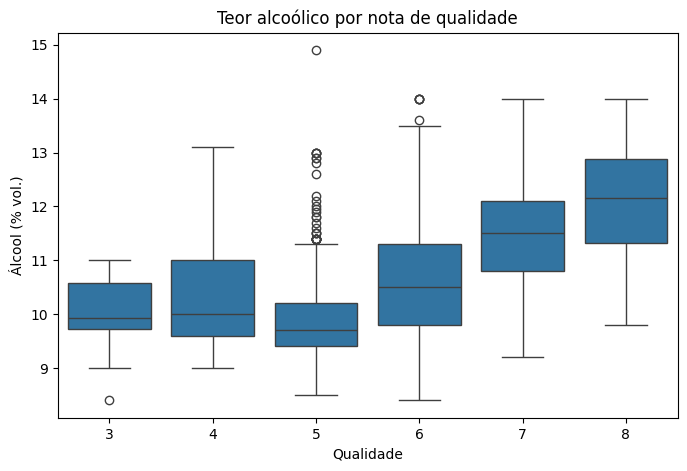

quality
3     9.925
4    10.000
5     9.700
6    10.500
7    11.500
8    12.150
Name: alcohol, dtype: float64
Nota com maior mediana: 8


In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Teor alcoólico por nota de qualidade")
plt.xlabel("Qualidade")
plt.ylabel("Álcool (% vol.)")
plt.show()

medianas = df.groupby("quality")["alcohol"].median()
print(medianas)
print("Nota com maior mediana:", medianas.idxmax())



D)

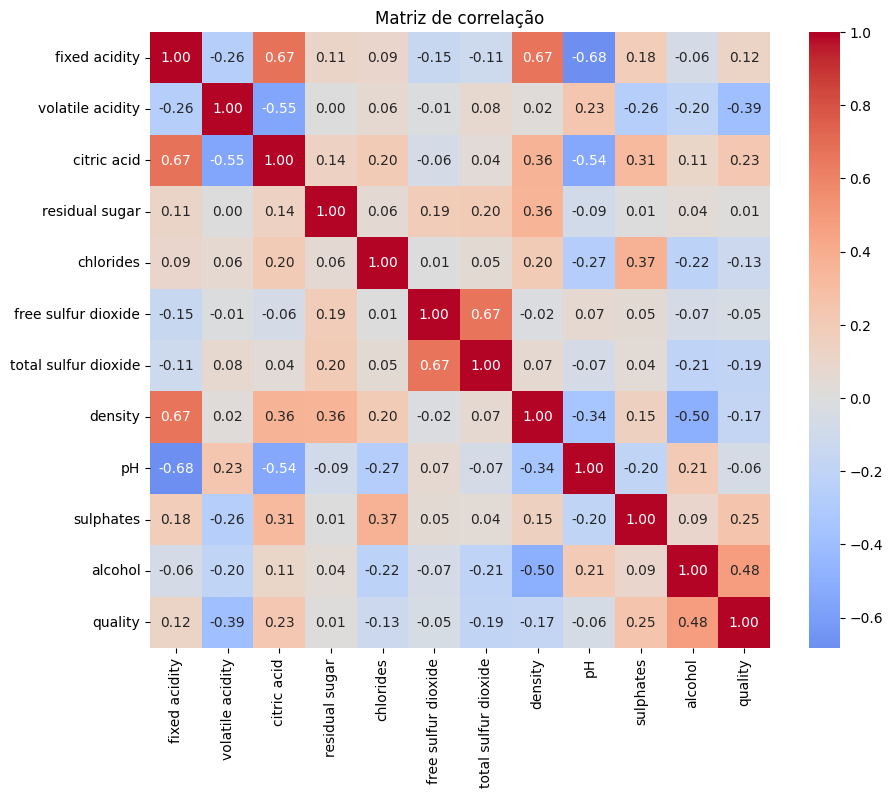

alcohol: 0.476
volatile acidity: -0.391


In [ ]:

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação")
plt.show()

corr_q = corr["quality"].drop("quality")
top2 = corr_q.abs().sort_values(ascending=False).head(2)
for var in top2.index:
    print(f"{var}: {corr_q[var]:.3f}")

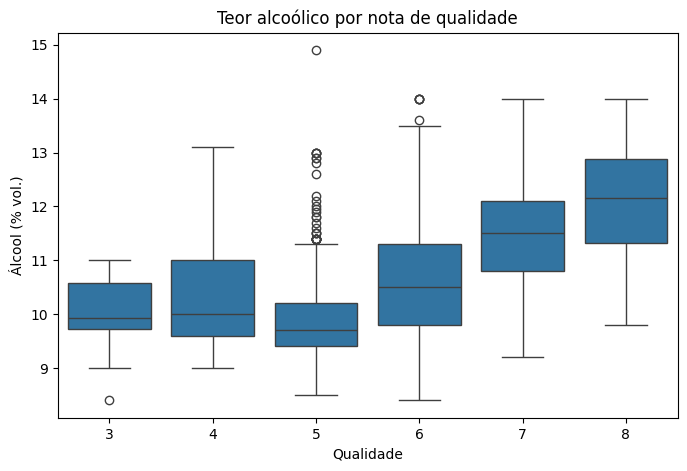

quality
3     9.925
4    10.000
5     9.700
6    10.500
7    11.500
8    12.150
Name: alcohol, dtype: float64
Nota com maior mediana: 8


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Teor alcoólico por nota de qualidade")
plt.xlabel("Qualidade")
plt.ylabel("Álcool (% vol.)")
plt.show()

medianas = df.groupby("quality")["alcohol"].median()
print(medianas)
print("Nota com maior mediana:", medianas.idxmax())

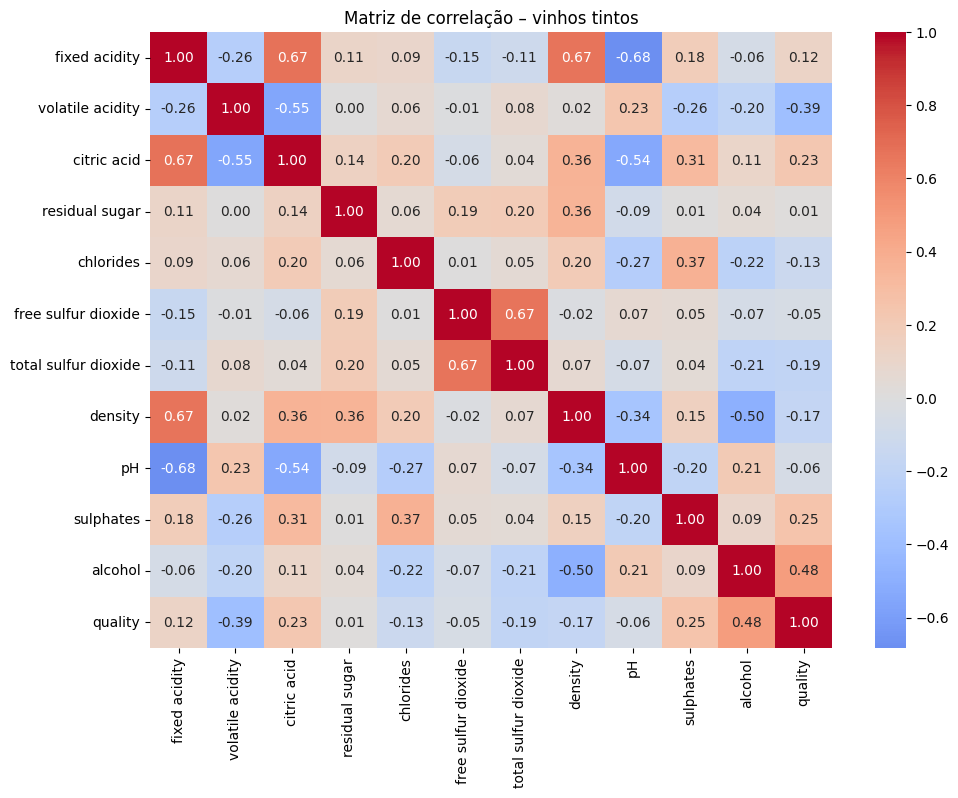

Duas variáveis com maior correlação (valor absoluto) com quality:
alcohol: +0.476
volatile acidity: -0.391


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação – vinhos tintos")
plt.show()

# Duas maiores correlações (valor absoluto) com quality
corr_q = corr["quality"].drop("quality")
top2 = corr_q.abs().sort_values(ascending=False).head(2)
print("Duas variáveis com maior correlação (valor absoluto) com quality:")
for var in top2.index:
    print(f"{var}: {corr_q[var]:+.3f}")